# Lecture 8 — The JOSH Solver: Production Radiative Transfer

*Stellar Spectroscopy from Scratch — rebuilding the physics of ATLAS and SYNTHE from first principles*

*Yuan-Sen Ting*

*Written in collaboration with **Claude Opus 4.8**, under the author's supervision. Schematics generated with **Gemini 3 Pro** (Nano Banana).*

*Every result in this book is checked against reference values computed with [**pykurucz**](https://arxiv.org/abs/2603.11693) — a pure-Python implementation of Kurucz's ATLAS12 and SYNTHE — shipped beside the lectures as small data files, so the notebooks need only NumPy to run.*

---

**Learning objectives.** By the end of this lecture you will be able to:

- Take the **moments** of the transfer equation and close them with the **Eddington approximation**, turning radiative transfer into a pair of moment equations for the mean intensity $J$ and the flux $H$.
- Read the production code's three precomputed tables — a fixed **optical-depth grid**, a discrete **lambda-like operator** `COEFJ`, and surface-flux weights `CH` — and say what each one does.
- Build the optical-depth scale with a **parabolic integrator**, map the source onto the fixed grid with **parabolic interpolation**, and solve the **scattering source function** by iteration.
- Assemble the emergent flux and reproduce the reference solar spectrum to **machine precision** — meaning agreement with the production JOSH code path and its tabulated operators and arithmetic, not an assertion that the moment approximation is exact radiative transfer — closing the gap the prescribed-thermal-source formal solution of Lecture 7 left against the production engine.

## Introduction

Lecture 7 solved radiative transfer with the **formal solution** under one approximation. The formal solution is exact for any specified source; the approximation was the *source* it was handed — the prescribed thermal value $S_\nu = B_\nu$, with no scattering coupling. That choice is exact wherever true absorption dominates, and it reproduced the solar spectrum to a part in a thousand, loosening to about ten percent only in the deepest cores. There, **scattering** is no longer negligible: the source is pulled away from $B_\nu$ toward the scattered radiation field, and a prescribed thermal source cannot follow it. Lecture 7 already wrote down the form this takes — the source becomes a mix of the thermal Planck term and the scattered mean intensity:

$$
S_\nu = \frac{\kappa^{\rm abs}_\nu\,B_\nu + \kappa^{\rm scat}_\nu\,J_\nu}{\kappa^{\rm abs}_\nu + \kappa^{\rm scat}_\nu}
        = (1-\alpha_\nu)\,B_\nu + \alpha_\nu\,J_\nu,
\qquad
\alpha_\nu \equiv \frac{\kappa^{\rm scat}_\nu}{\kappa^{\rm abs}_\nu + \kappa^{\rm scat}_\nu}.
$$

The difficulty Lecture 7 deferred is the **mean intensity** $J_\nu$: it is an angular moment of the radiation field at each depth, and that field in turn depends nonlocally on $S_\nu$ throughout the atmosphere — so the source and the field are coupled, and we can no longer just read $S$ off the temperature structure. The production code resolves this with a **moment method** on a fixed optical-depth grid, due to Avrett & Loeser and known in the Kurucz codes as **JOSH**. It reduces the angular transfer problem to two coupled ordinary differential equations for the moments, discretises them as a precomputed matrix, and iterates the source to self-consistency. This lecture rebuilds it step by step, and the payoff is the spectrum to machine precision.

![The JOSH moment solver: opacity to optical depth, a map onto a fixed Eddington grid, a scattering iteration for the source, and a weighted surface flux.](resources/figures/s7_josh.png)

## The moment equations and the Eddington closure

This is the conceptual core of the lecture. Start from the plane-parallel transfer equation of Lecture 7, $\mu\,dI/d\tau = I - S$, where $\tau$ is the optical depth of Lecture 1, and take **moments** in the angle cosine $\mu$ — that is, multiply by powers of $\mu$ and average over solid angle. Assuming azimuthal symmetry, the $d\Omega$ integral reduces to the $\mu$ integrals below. Define the first three moments of the intensity,

$$
J = \tfrac12\!\int_{-1}^{1} I\,d\mu, \qquad
H = \tfrac12\!\int_{-1}^{1} I\,\mu\,d\mu, \qquad
K = \tfrac12\!\int_{-1}^{1} I\,\mu^2\,d\mu,
$$

the **mean intensity** $J$, the **Eddington flux** $H$ (the physical flux is $F = 4\pi H$), and the second moment $K$. Taking the zeroth and first moments of the transfer equation gives

$$
\frac{dH}{d\tau} = J - S, \qquad \frac{dK}{d\tau} = H.
$$

This is two equations in three unknowns ($J, H, K$) — not closed. The **Eddington approximation** closes it: deep in the atmosphere the radiation field is nearly isotropic, so $K = \tfrac13 J$ (for an isotropic field $\langle\mu^2\rangle = 1/3$). In the simplified Eddington closure used here we take the Eddington factor $f \equiv K/J = \tfrac13$, extending this deep-atmosphere relation as a closure across the whole grid; the surface boundary condition partly compensates for the fact that the field is not isotropic near $\tau = 0$. With $K = fJ$ the second moment equation becomes $H = d(fJ)/d\tau$; differentiating it and substituting into the first moment equation eliminates both $H$ and $K$, leaving

$$
\frac{d^2(fJ)}{d\tau^2} = J - S, \qquad f = \tfrac13,
$$

a single second-order equation for $J$ given the source $S$. We close it with the usual **Eddington surface boundary condition**, $H(0) = J(0)/\sqrt3$, which approximates the no-incoming-radiation boundary within the closure (it does not follow exactly from $I(\mu<0)=0$), together with a diffusion condition at depth: at large optical depth the radiation field approaches the local thermal field, with a flux set by the source gradient. Because the equation is linear in $S$, so is its solution: $J = \Lambda_{\rm JOSH}[S]$, the lambda-like operator of this moment closure. Discretised on a fixed optical-depth grid it becomes a **matrix**, and that matrix is one of the tables the production code ships.

In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt

# shared plot styling for the whole notebook
plt.rcParams.update({"figure.figsize": (7.2, 4.3), "figure.dpi": 120, "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11.5})

# the production code's precomputed JOSH tables, all on the fixed optical-depth grid
REF = pathlib.Path("..") / "reference"
T = np.load(REF / "josh_tables.npz")

# the fixed optical-depth grid, 51 points, surface -> deep
XTAU = T["xtau"]

# surface-flux weights: H(0) = sum(CH * S)
CH = T["ch"]

# the discrete lambda-like operator: J = COEFJ @ S on the grid
COEFJ = T["coefj"]

# column mass of the model atmosphere, 80 layers [g/cm^2]
RHOX = T["rhox"]

# number of grid points we will solve on
NXTAU = XTAU.size

# report the grid extent and the shapes of the two operators
print(f"fixed grid: {NXTAU} points, tau = {XTAU[0]:.3g} .. {XTAU[-1]:.3g}")
print(f"COEFJ is {COEFJ.shape}, CH is {CH.shape}, atmosphere has {RHOX.size} layers")

fixed grid: 51 points, tau = 0 .. 20
COEFJ is (51, 51), CH is (51,), atmosphere has 80 layers


## The three tables, and what they mean

The method rests on three precomputed objects, all defined on the **fixed optical-depth grid** `XTAU` (51 points spanning $\tau \approx 10^{-5}$ at the surface to $\tau \approx 20$ deep). The operator can be fixed because, once each wavelength is mapped onto its own optical-depth coordinate, the closure equations have the same form; the wavelength dependence enters only through the source $S$, the scattering fraction $\alpha$, and the depth-to-$\tau$ mapping.

- **`COEFJ`** is the discrete lambda-like operator $\Lambda_{\rm JOSH}$. Given the source function sampled on the grid, $J = \texttt{COEFJ} \cdot S$ returns the mean intensity on the grid — it *is* the solution of the moment equations, packaged as a matrix multiply. Its diagonal, $\texttt{COEFJ}_{kk}$, is how strongly the local source feeds the local mean intensity, and it is the dominant term.
- **`CH`** turns the converged source into the emergent **surface flux**: $H(0) = \sum_k \texttt{CH}_k\,S_k$. It is the discrete form of the flux integral, the moment-method counterpart of the $E_2$ kernel from Lecture 7. Throughout this notebook the returned quantity is the Eddington flux $H$; the physical flux is $F = 4\pi H$, and that constant factor cancels in the normalised spectrum.
- **`XTAU`** is the grid both are built on.

Let us look at them.

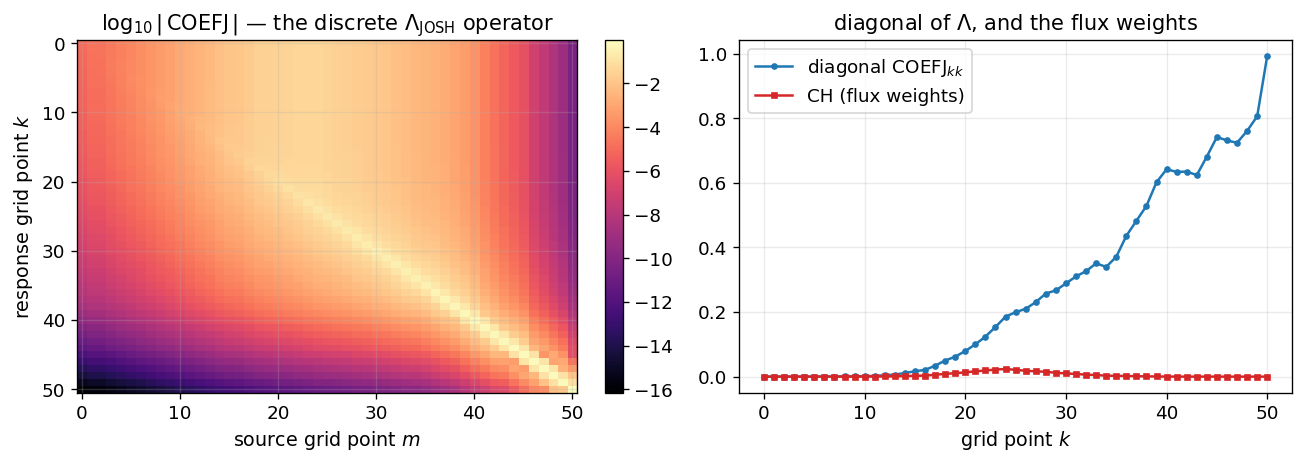

In [2]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.0))

# left: the full operator as a heat map (log scale so the off-diagonal tails show)
im = a1.imshow(np.log10(np.abs(COEFJ) + 1e-30), cmap="magma", aspect="auto")
a1.set_title(r"$\log_{10}|\,$COEFJ$\,|$ — the discrete $\Lambda_{\rm JOSH}$ operator")
a1.set_xlabel("source grid point $m$"); a1.set_ylabel("response grid point $k$")
fig.colorbar(im, ax=a1, fraction=0.046)

# right: the dominant diagonal of Lambda alongside the surface-flux weights
a2.plot(np.arange(NXTAU), np.diag(COEFJ), "o-", ms=3, label="diagonal COEFJ$_{kk}$")
a2.plot(np.arange(NXTAU), CH, "s-", ms=3, color="C3", label="CH (flux weights)")
a2.set_xlabel("grid point $k$"); a2.set_title("diagonal of $\\Lambda$, and the flux weights")

a2.legend(); fig.tight_layout(); plt.show()

The operator is strongly diagonal — the mean intensity at a point is dominated by the source there, with smaller contributions from neighbouring depths — exactly the local-plus-tails structure of $\Lambda$. The flux weights `CH` are concentrated near the surface points: the emergent flux is set by the source in the top few optical depths, the same Eddington–Barbier intuition as Lecture 7, now as a discrete sum.

## The inputs: opacity, scattering, and the source

For each wavelength the solver needs, at every atmospheric depth, four opacity quantities and a source function. The four opacities we built in earlier lectures and read here as reference arrays of shape (depth, wavelength):

- `cont_abs` $=\kappa^{\rm abs}_{\rm cont}$ — the **continuum absorption** of Lecture 3 (mostly H$^-$).
- `cont_scat` $=\kappa^{\rm scat}_{\rm cont}$ — the **continuum scattering** of Lecture 3 (Rayleigh + Thomson).
- `line_abs` $=\kappa^{\rm abs}_{\rm line}$ — the **line absorption** of Lecture 5 (the forest of Voigt profiles).
- `line_scat` $=\kappa^{\rm scat}_{\rm line}$ — a placeholder for line scattering; in this solar window's reference setup it is exactly zero.

The **source function**, by contrast, we do not read — we compute it. In the local thermodynamic equilibrium (LTE) this book works in, the thermal source is the **Planck function** $B_\nu(T)$ of Lecture 1 — per unit frequency, to match Kurucz's source arrays — evaluated at each depth's temperature and each wavelength point's frequency. The next section makes the LTE identity precise and computes $B_\nu$ inline; here we load only the opacities, the wavelength grid, and the per-depth temperatures of the solar model.

These opacities are **mass extinction coefficients**, so they convert to optical depth by $d\tau_\lambda = \kappa_\lambda\,dm$, with $m$ the column mass increasing inward — the relation we integrate in Step 1. From the opacities and the source we form, at each depth, the **total extinction** $\kappa^{\rm abs}+\kappa^{\rm scat}$, the **scattering fraction** $\alpha = \kappa^{\rm scat}/(\kappa^{\rm abs}+\kappa^{\rm scat})$, and the **absorption-weighted source**

$$
\bar S = \frac{\kappa^{\rm abs}_{\rm cont}\,S_{\rm cont} + \kappa^{\rm abs}_{\rm line}\,S_{\rm line}}
              {\kappa^{\rm abs}_{\rm cont} + \kappa^{\rm abs}_{\rm line}},
$$

which is the thermal ($B$-like) part of the source, before scattering mixes in $J$. The scattering opacities are deliberately absent from $\bar S$: their emissivity is the separate $\alpha J$ term that the iteration of Step 3 supplies, so $\bar S$ holds only the thermal emissivity divided by the absorptive opacity.

In [3]:
# the per-wavelength opacities built in earlier lectures
D = np.load(REF / "diag.npz")

# the four opacity arrays, shape (depth, wl)
cont_abs  = D["continuum_absorption"].astype(float)   # kappa_abs continuum  (depth, wl)
cont_scat = D["continuum_scattering"].astype(float)    # kappa_scat continuum
line_abs  = D["line_opacity"].astype(float)            # kappa_abs lines
line_scat = D["line_scattering"].astype(float)         # kappa_scat lines

# the wavelength axis and the reference spectra we will compare against
wl        = D["wavelength"].astype(float)              # nm
flux_total_ref = D["flux_total"]; flux_cont_ref = D["flux_continuum"]

# the solar model's per-depth temperatures: the source function is built FROM these,
# not read from the reference -- the Planck function of Lecture 1 (next section)
Tdepth = np.load(REF / "atmosphere.npz")["temperature"].astype(float)   # K, 80 layers

print(f"{cont_abs.shape[0]} depths x {wl.size} wavelengths, {wl[0]:.1f}-{wl[-1]:.1f} nm")

80 depths x 5941 wavelengths, 500.0-510.0 nm


## The source function in LTE is the Planck function

The one physical quantity left to supply is the **thermal source function** $S_\nu$ — the thermal emissivity divided by the absorptive opacity. (The *total* source entering the transfer is then the extinction-weighted mixture of this thermal term and the scattering emissivity $\alpha J$; that mixing is the iteration's job, Step 3.) We do not read the thermal source from the reference — we **compute** it, because in LTE it has a closed form. Throughout this section the Planck function is the *per-frequency* $B_\nu$: although the grid is labelled by wavelength, Kurucz's source arrays are per unit frequency, so the subscript only labels the wavelength point and all source functions below are $B_\nu(T)$. The production code builds its continuum source as $S_{\rm cont} = B_\nu\,(1-e^{-h\nu/kT})/(\texttt{BFUDGE} - e^{-h\nu/kT})$, where `BFUDGE` is a departure factor that would carry any non-LTE level populations. In strict LTE the level populations are thermal, so $\texttt{BFUDGE}\equiv 1$, and the denominator collapses to the stimulated-emission factor $1-e^{-h\nu/kT}$ — exactly the numerator's factor — leaving

$$
S_{\rm cont} = \frac{B_\nu\,(1-e^{-h\nu/kT})}{1 - e^{-h\nu/kT}} = B_\nu(T) .
$$

The **line** source is the same story: with no line scattering ($\kappa^{\rm scat}_{\rm line}\equiv 0$ here) and thermal populations, the line emissivity is also Boltzmann-thermal, so $S_{\rm line} = B_\nu(T)$ too. Both source functions therefore reduce, *to the bit*, to the single Planck function at the local temperature. So rather than read `slinec`/`line_source` from the reference, we evaluate $B_\nu$ inline — the identical overflow-safe Kurucz form, constants, and literal $1.47439\times10^{-2}$ prefactor we wrote in Lecture 1 — and feed that into the transfer. We then verify, before using it, that the inline $B_\nu$ reproduces the reference source arrays to machine precision; agreement confirms the LTE identity holds and that no source function need ever be read as an input.

In [4]:
# the Planck function B_nu(T), the exact overflow-safe Kurucz form of Lecture 1:
# the 1.47439e-2 prefactor is 2h/c^2 with nu rescaled by 1e15 (Kurucz's historical literal),
# and e^{-x}/(1-e^{-x}) is the photon occupation factor written so the Wien tail never overflows
H_PLANCK = 6.62607015e-27       # Planck constant   [erg s]   (the Lecture 1 constants)
K_BOLTZ  = 1.380649e-16         # Boltzmann constant [erg/K]
C_NM     = 2.99792458e17        # speed of light    [nm/s]    (so nu = C_NM / wl_nm)

def planck_nu(freq_hz, temperature):
    """Planck B_nu(T) [CGS], the exact overflow-safe Kurucz form of Lecture 1."""
    x = H_PLANCK * freq_hz / (K_BOLTZ * np.asarray(temperature, float))   # x = h nu / kT
    ehvkt = np.exp(-x)                                                     # <= 1: never overflows
    return 1.47439e-2 * (freq_hz / 1e15)**3 * ehvkt / (1.0 - ehvkt)

# evaluate B_nu at every (depth, wavelength): frequency from the grid, temperature from the model
nu = C_NM / wl                                          # [Hz]
B_nu = planck_nu(nu[None, :], Tdepth[:, None])          # (depth, wl)

# PROOF the substitution is exact: compare inline B_nu to the reference source arrays.
# in LTE these are equal -- slinec = line_source = B_nu -- so this must match to machine precision
ref_slinec = D["slinec"].astype(float)
ref_lsource = D["line_source"].astype(float)

# relative difference of the inline Planck against each stored reference source
rel_c = np.abs(B_nu - ref_slinec) / np.abs(ref_slinec)
rel_l = np.abs(B_nu - ref_lsource) / np.abs(ref_lsource)

print(f"inline B_nu vs reference slinec     : max rel diff = {rel_c.max():.2e}  (LTE: = 0 to roundoff)")
print(f"inline B_nu vs reference line_source: max rel diff = {rel_l.max():.2e}")
print(f"reference line_scattering is exactly zero: {np.all(line_scat == 0.0)}")

# USE the inline B_nu as BOTH the continuum and the line source -- no source is read as input
S_cont = B_nu
S_line = B_nu

inline B_nu vs reference slinec     : max rel diff = 2.62e-15  (LTE: = 0 to roundoff)
inline B_nu vs reference line_source: max rel diff = 2.62e-15
reference line_scattering is exactly zero: True


From those raw arrays a small helper builds the three quantities the moment solver needs at every depth: the total extinction, the scattering fraction $\alpha$, and the absorption-weighted thermal source $\bar S$. The `EPS` floor mirrors the Fortran's tiny constant, used to keep divisions safe rather than to change any physics.

In [5]:
# Fortran's tiny floor, used to keep divisions safe
EPS = 1e-38

def source_and_alpha(acont, scont, aline, sline, sigmac, sigmal):
    """Total extinction, scattering fraction, and absorption-weighted source per depth."""
    # total extinction = absorption + scattering, continuum + lines
    abtot = np.maximum(acont + aline + sigmac + sigmal, EPS)

    # scattering fraction alpha, clipped into [0,1]
    alpha = np.clip((sigmac + sigmal) / abtot, 0.0, 1.0)

    # the thermal source divides the thermal emissivity by the absorptive opacity only
    denom = acont + aline

    # opacity-weighted blend of the continuum and line source functions
    sbar = np.where(denom > 0, (acont*scont + aline*sline)/denom, scont)

    return abtot, alpha, sbar

## Step 1 — optical depth, by parabolic integration

The moment equations live in optical depth, so first we turn the mass extinction into a $\tau_\lambda$ scale by integrating $d\tau_\lambda = \kappa_\lambda\,dm$ over the column mass `RHOX`, exactly as in Lecture 7 — but here we use the production code's **parabolic** quadrature rather than the trapezoid, because the same routine is used to build the grid the operator was tabulated on, and we want the optical-depth scale to match to the bit.

You do not need to memorise the coefficient algebra below; the point to retain is that `parcoe`/`integ` is a local parabolic quadrature that the production code applies everywhere. The routine `parcoe` fits, on every interval, a parabola $f(x) \approx a + bx + cx^2$ through three neighbouring points — where here the independent variable $x$ is the column mass `RHOX`, and $\tau_\lambda$ is the *output* of the integration, not the variable being fitted. It then forces the first one or two interior intervals near the boundary to use linear fits, where a stable neighbouring parabola is not available, and blends each parabola with its neighbour by curvature weight — a mild smoothing that keeps the integrand well behaved near the boundaries.

In [6]:
def parcoe(f, x):
    """Parabolic coefficients a,b,c per interval (Kurucz PARCOE)."""
    n = f.size
    a = np.zeros(n); b = np.zeros(n); c = np.zeros(n)
    if n == 1:                                                      # single point: constant
        a[0] = f[0]; return a, b, c

    # linear fit at the two endpoints (no interior neighbour for a parabola)
    b[0]  = (f[1]-f[0])/(x[1]-x[0]);     a[0]  = f[0]-x[0]*b[0]
    n1 = n-1
    b[-1] = (f[-1]-f[n1-1])/(x[-1]-x[n1-1]); a[-1] = f[-1]-x[-1]*b[-1]
    if n == 2: return a, b, c                                       # two points: linear only

    # fit a parabola through three consecutive points on each interior interval
    for j in range(1, n1):                                          # parabola through 3 points
        j1 = j-1
        d = (f[j]-f[j1])/(x[j]-x[j1])                               # local slope
        c[j] = f[j+1]/((x[j+1]-x[j])*(x[j+1]-x[j1])) + \
               (f[j1]/(x[j+1]-x[j1]) - f[j]/(x[j+1]-x[j]))/(x[j]-x[j1])
        b[j] = d - (x[j]+x[j1])*c[j]
        a[j] = f[j1] - x[j1]*d + x[j]*x[j1]*c[j]

    # force the first one or two interior intervals to be linear (no curvature)
    c[1] = 0.0; b[1] = (f[2]-f[1])/(x[2]-x[1]); a[1] = f[1]-x[1]*b[1]   # force pts 2,3 linear
    if n > 3:
        c[2] = 0.0; b[2] = (f[3]-f[2])/(x[3]-x[2]); a[2] = f[2]-x[2]*b[2]

    # blend each parabola with its neighbour, weighted by relative curvature
    for j in range(1, n1):                                          # curvature-weighted blend
        if c[j] == 0.0: continue
        j1 = min(j+1, n-1); denom = abs(c[j1]) + abs(c[j])
        wt = abs(c[j1])/denom if denom > 0 else 0.0                 # weight by neighbour curvature
        a[j] = a[j1]+wt*(a[j]-a[j1]); b[j] = b[j1]+wt*(b[j]-b[j1]); c[j] = c[j1]+wt*(c[j]-c[j1])

    a[n1-1] = a[-1]; b[n1-1] = b[-1]; c[n1-1] = c[-1]               # copy last interval coeffs
    return a, b, c

With the per-interval coefficients in hand, `integ` accumulates the integral analytically: on each interval it integrates that interval's parabola in closed form and adds it to the running total, so the result is the cumulative optical depth $\tau_\lambda$ down through the atmosphere. The two routines together are the Kurucz `PARCOE`/`INTEG` pair.

In [7]:
def integ(x, f, start):
    """Cumulative integral of f dx using each interval's left-point parabola (Kurucz INTEG)."""
    a, b, c = parcoe(f, x)                       # per-interval parabola coefficients
    out = np.zeros(f.size); out[0] = start       # seed with the surface boundary value
    for i in range(f.size-1):
        dx = x[i+1]-x[i]                          # width of this interval
        # closed-form integral of a + b x + c x^2 across [x_i, x_{i+1}]
        term = a[i] + 0.5*b[i]*(x[i+1]+x[i]) + (c[i]/3.0)*((x[i+1]+x[i])*x[i+1] + x[i]*x[i])
        out[i+1] = out[i] + term*dx              # accumulate the running integral
    return out

## Step 2 — map the source onto the fixed grid

The atmosphere has 80 depth points, with a $\tau_\lambda$ scale that differs at every wavelength; the operator `COEFJ` lives on the fixed 51-point grid `XTAU`. So we interpolate the absorption-weighted source $\bar S$ and the scattering fraction $\alpha$ from the atmosphere's $\tau_\lambda$ onto `XTAU`. The production code uses the same parabolic interpolation everywhere — the `MAP1` routine — so we reproduce it rather than reach for a library spline; the small differences in interpolation scheme are exactly what would spoil bit-level agreement.

The body of `map1` below is long and faithfully Fortran-shaped, but its conceptual role is simple, and that is all you need to retain: **given values on the atmosphere grid, `MAP1` returns values on `XTAU` using the same local parabolic rule as the production code.** It walks the new abscissae in order, and for each one selects a local parabola — a forward fit, a backward fit, or a curvature-weighted blend of the two — choosing linear fits near the ends where a parabola has no neighbour. The branching is bookkeeping to pick the right three points; the arithmetic is the same parabola as `parcoe`.

Where a grid point lies **above** the top of the model atmosphere — at an optical depth smaller than that of the topmost mass layer, $\tau < \tau_\lambda[0]$ — there is nothing to interpolate from, so the source is held at its surface value. That surface masking matters in strong lines, whose opacity lifts $\tau_\lambda[0]$ to non-negligible values.

In [8]:
def map1(xold, fold, xnew):
    """Parabolic interpolation of fold(xold) onto xnew (Kurucz MAP1)."""
    nold, nnew = xold.size, xnew.size
    fnew = np.zeros(nnew)
    if nold == 0 or nnew == 0: return fnew

    # 1-based padding so the index arithmetic matches the original Fortran exactly
    xo = np.empty(nold+1); fo = np.empty(nold+1); xo[1:] = xold; fo[1:] = fold
    l = 2; ll = 0                                          # l: bracketing index; ll: last one used
    cfor = bfor = afor = cbac = bbac = abac = a = b = c = 0.0

    for k in range(1, nnew+1):
        xk = xnew[k-1]                                     # the new abscissa to evaluate at
        while True:
            if xk < xo[l]:                                 # xk now bracketed by [xo[l-1], xo[l]]
                if l == ll: break                          # reuse the parabola from the last point
                if l == 2 or l == 3:                       # near the top: linear fit only
                    l = min(nold, l); c = 0.0
                    b = (fo[l]-fo[l-1])/(xo[l]-xo[l-1]); a = fo[l]-xo[l]*b; ll = l; break
                l1 = l-1
                if l > ll+1 or l == 3 or l == 4:           # backward parabola (3 points ending at l)
                    l2 = l-2
                    d = (fo[l1]-fo[l2])/(xo[l1]-xo[l2])
                    cbac = fo[l]/((xo[l]-xo[l1])*(xo[l]-xo[l2])) + \
                           (fo[l2]/(xo[l]-xo[l2]) - fo[l1]/(xo[l]-xo[l1]))/(xo[l1]-xo[l2])
                    bbac = d - (xo[l1]+xo[l2])*cbac
                    abac = fo[l2] - xo[l2]*d + xo[l1]*xo[l2]*cbac
                    if l >= nold: c, b, a, ll = cbac, bbac, abac, l; break   # no forward room
                else:
                    cbac, bbac, abac = cfor, bfor, afor    # reuse previous forward fit as backward
                    if l == nold: c, b, a, ll = cbac, bbac, abac, l; break
                d = (fo[l]-fo[l1])/(xo[l]-xo[l1])          # forward parabola (3 points starting at l1)
                cfor = fo[l+1]/((xo[l+1]-xo[l])*(xo[l+1]-xo[l1])) + \
                       (fo[l1]/(xo[l+1]-xo[l1]) - fo[l]/(xo[l+1]-xo[l]))/(xo[l]-xo[l1])
                bfor = d - (xo[l]+xo[l1])*cfor
                afor = fo[l1] - xo[l1]*d + xo[l]*xo[l1]*cfor
                wt = abs(cfor)/(abs(cfor)+abs(cbac)) if abs(cfor) != 0 else 0.0   # curvature weight
                a = afor+wt*(abac-afor); b = bfor+wt*(bbac-bfor); c = cfor+wt*(cbac-cfor); ll = l; break
            l += 1                                         # xk lies deeper: advance the bracket
            if l > nold:                                   # off the deep end: linear fit
                l = min(nold, l); c = 0.0
                b = (fo[l]-fo[l-1])/(xo[l]-xo[l-1]); a = fo[l]-xo[l]*b; ll = l; break
        fnew[k-1] = a + (b + c*xk)*xk                      # evaluate the chosen parabola at xk
    return fnew

## Step 3 — the scattering source, by iteration

Now the heart of the method, and the part this lecture owns. On the grid we want the source function that is consistent with the radiation field it produces. With the absorption-weighted source $\bar S$ and the operator $J = \texttt{COEFJ}\cdot S$ of the Eddington closure, the scattering relation $S = (1-\alpha)\bar S + \alpha J$ — written down in Lecture 7 — becomes a **linear fixed point on the grid**:

$$
S_k = (1-\alpha_k)\,\bar S_k + \alpha_k \sum_m \texttt{COEFJ}_{km}\,S_m .
$$

When the scattering fraction $\alpha$ is zero this collapses to $S = \bar S$ — the pure-absorption case Lecture 7 handled with a prescribed thermal source. When $\alpha > 0$ the source is pulled toward $J$ rather than held at $\bar S$; in the optically thin surface layers, where the radiation field is no longer thermalised, this is where the iteration does its work.

We solve the fixed point by a **backward Gauss–Seidel sweep**, running from the deepest grid point up to the surface. The direction is not arbitrary: at depth the radiation field is strongly thermalised, $S \approx \bar S$, so that end is already near its answer; sweeping bottom-up propagates this stable, physically anchored value outward into the scattering-dominated surface layers where the correction is largest. To get the per-point update, take the fixed-point equation $S_k = (1-\alpha_k)\bar S_k + \alpha_k\sum_m \texttt{COEFJ}_{km}S_m$, split the sum into its diagonal $m=k$ term and the rest, and move the diagonal term to the left-hand side; solving for the updated $S_k$ leaves the $1 - \alpha_k\,\texttt{COEFJ}_{kk}$ denominator below. Subtracting the current value from that result gives the increment applied at each point,

$$
\Delta S_k = \frac{\alpha_k\,(\texttt{COEFJ}\cdot S)_k + (1-\alpha_k)\bar S_k - S_k}{1 - \alpha_k\,\texttt{COEFJ}_{kk}},
$$

repeated until every relative change falls below $10^{-5}$. The update is **in place**: the dot product $(\texttt{COEFJ}\cdot S)_k$ uses the current working vector, so deeper points already visited in the backward sweep contribute their freshly updated values while the not-yet-visited upper points still hold their previous-iteration values — this is what makes it Gauss–Seidel rather than Jacobi, and it is what accelerates convergence. The production code carries this iteration in **single precision** (the original Fortran used `REAL*4` arrays here), so we do too — it is the one place where the working precision is part of the specification.

In [9]:
ITER_TOL, MAX_ITER = 1e-5, 51       # relative tolerance and iteration cap
COEFJ_DIAG = np.diag(COEFJ).copy()   # the diagonal of Lambda, reused below

def iterate_source(sbar_grid, alpha_grid):
    """Solve S = (1-alpha) sbar + alpha (COEFJ @ S) by backward Gauss-Seidel, float32."""
    # work in single precision throughout: this is part of the production specification
    co = COEFJ.astype(np.float32)
    xs = sbar_grid.astype(np.float32)                 # initial guess: the thermal source
    al = alpha_grid.astype(np.float32)

    # (1-alpha) * sbar, the constant thermal term, precomputed once
    sbar_mod = (sbar_grid * (1.0 - alpha_grid)).astype(np.float32)
    # the per-point Gauss-Seidel denominator 1 - alpha * COEFJ_kk
    diag = (1.0 - alpha_grid * COEFJ_DIAG).astype(np.float32)
    tol, eps = np.float32(ITER_TOL), np.float32(EPS)

    for _ in range(MAX_ITER):
        converged = True

        # backward sweep: deepest (thermalised) point first, propagating up to the surface
        for k in range(NXTAU-1, -1, -1):              # backward sweep: deepest point first
            j_k = np.float32(np.dot(co[k], xs))       # (COEFJ @ S)_k, in place -> Gauss-Seidel
            # the per-point increment from solving the diagonal-isolated fixed point
            delta = (j_k*al[k] + sbar_mod[k] - xs[k]) / diag[k]
            if (abs(delta/xs[k]) if xs[k] != 0 else np.inf) > tol:   # track relative change
                converged = False
            xs[k] = max(xs[k] + delta, eps)           # apply update, floored to stay positive

        if converged:                                 # stop once every point is below tolerance
            break
    return xs.astype(np.float64)

## Step 4 — the surface flux, and the whole solver

The last step is owned by this lecture too: the converged source on the grid gives the emergent Eddington flux by the discrete weighted sum $H(0) = \sum_k \texttt{CH}_k\,S_k$ — a single dot product `CH @ S` of the surface-flux weights with the source. Assembling the four steps — optical depth, map to the grid, iterate the source, weight for the flux — is the complete `solve_josh` for one wavelength. One bookkeeping detail: `INTEG` needs the column mass increasing from the surface inward; our `RHOX` already is, so no reversal is needed here.

In [10]:
def solve_josh(acont, scont, aline, sline, sigmac, sigmal):
    """Emergent Eddington flux H(0) at one wavelength via the JOSH moment method."""
    # build total extinction, scattering fraction, and thermal source at every depth
    abtot, alpha, sbar = source_and_alpha(acont, scont, aline, sline, sigmac, sigmal)
    tau = integ(RHOX, abtot, abtot[0]*RHOX[0])             # step 1: optical depth (seed = top dtau)

    sbar_g  = np.maximum(map1(tau, sbar,  XTAU), EPS)        # step 2: map source onto the grid
    alpha_g = np.clip(   map1(tau, alpha, XTAU), 0.0, 1.0)   #         and the scattering fraction

    # grid points above the atmosphere top have nothing to interpolate from:
    # hold them at the surface values (matters in strong, opaque line cores)
    above = XTAU < tau[0]
    if above.any():
        sbar_g[above] = max(sbar[0], EPS); alpha_g[above] = np.clip(alpha[0], 0.0, 1.0)

    S = iterate_source(sbar_g, alpha_g)                     # step 3: scattering iteration
    return float(CH @ S)                                    # step 4: CH-weighted surface flux H(0)

# the continuum is the same solver with the line terms switched off
def solve_continuum(acont, scont, sigmac):
    # zero line opacity and zero line scattering
    zero = np.zeros_like(acont)
    return solve_josh(acont, scont, zero, scont, sigmac, zero)

print("solver assembled")

solver assembled


## A worked example: one line core, one continuum point

Before running the whole window, watch the iteration act on a single wavelength. We pick the **deepest line core** in the band and a nearby **continuum** point, and look at the source function on the grid before and after the scattering iteration.

The two points sit at opposite ends of the scattering scale, and not in the way generic intuition expects. The continuum point is **scattering-dominated at the surface**: in the thin, cool top layers the continuum absorption (H$^-$) is vanishingly small while Rayleigh and Thomson scattering are not, so the scattering fraction climbs to $\alpha \to 1$ there, and the iteration moves the source substantially as it couples $S$ to the nonlocal field $J$. The deep line core is the reverse: in this LTE solar window the line is **pure absorption** ($\kappa^{\rm scat}_{\rm line}\equiv 0$), and its enormous opacity swamps the continuum scattering at every depth, so $\alpha \approx 0$ throughout and the iteration leaves the source essentially untouched. The panel titles report each point's maximum $\alpha$ along the column, so they read $\alpha_{\max}\approx 1$ for the continuum point and $\alpha_{\max}\approx 0$ for the line core.

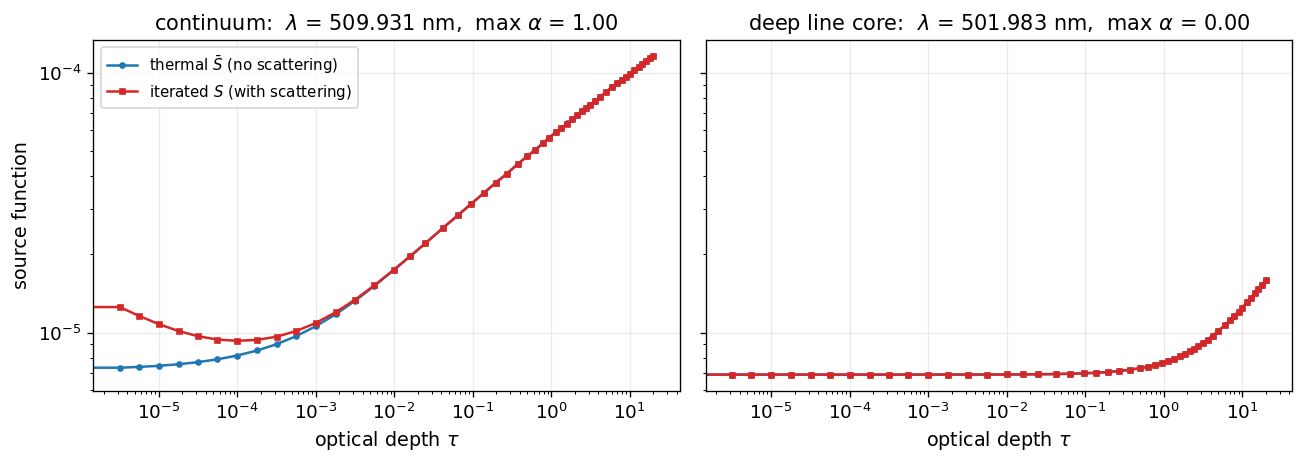

In [11]:
ref_spec = flux_total_ref / flux_cont_ref
kc = int(np.argmin(ref_spec))                              # deepest line core
kk = int(np.argmin(np.abs(ref_spec - 1.0)))               # a continuum point (spectrum ~ 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)
for ax, k, name in [(axes[0], kk, "continuum"), (axes[1], kc, "deep line core")]:
    # run the first three pipeline steps by hand so we can plot the source before and after
    abtot, alpha, sbar = source_and_alpha(cont_abs[:,k], S_cont[:,k], line_abs[:,k],
                                          S_line[:,k], cont_scat[:,k], line_scat[:,k])
    tau = integ(RHOX, abtot, abtot[0]*RHOX[0])             # optical depth for this wavelength

    sbar_g  = np.maximum(map1(tau, sbar,  XTAU), EPS)        # thermal source on the grid
    alpha_g = np.clip(   map1(tau, alpha, XTAU), 0.0, 1.0)   # scattering fraction on the grid
    above = XTAU < tau[0]                                    # mask grid points above the atmosphere
    if above.any(): sbar_g[above] = max(sbar[0], EPS); alpha_g[above] = np.clip(alpha[0],0,1)

    S = iterate_source(sbar_g, alpha_g)                     # the scattering iteration

    # compare the thermal source (no scattering) with the iterated source (with scattering)
    ax.loglog(XTAU, sbar_g, "o-", ms=3, label=r"thermal $\bar S$ (no scattering)")
    ax.loglog(XTAU, S, "s-", ms=3, color="C3", label="iterated $S$ (with scattering)")
    ax.set_title(f"{name}:  $\\lambda$ = {wl[k]:.3f} nm,  max $\\alpha$ = {alpha_g.max():.2f}")
    ax.set_xlabel(r"optical depth $\tau$")

axes[0].set_ylabel("source function"); axes[0].legend(loc="upper left", fontsize=9)
fig.tight_layout(); plt.show()

In the line-core panel the two curves lie on top of each other — with $\alpha\approx 0$ the source never leaves $\bar S$, and this pure-absorption line is exactly the case Lecture 7 already handled. In the continuum panel the iterated source peels away from the thermal source in the surface layers, where $\alpha\to 1$: those layers are dominated by nonlocal scattering, the local source is pulled toward the mean intensity $J$ rather than set by the local $\bar S$, and that coupling is precisely the part a prescribed thermal source cannot capture. The lesson is that whether the iteration matters is set by the scattering fraction $\alpha$, not by whether the wavelength sits in a line or the continuum.

## The full spectrum, to machine precision

Now run the solver across all wavelengths — the line flux with every opacity term, the continuum flux with the lines switched off — and take the ratio for the normalised spectrum. This is the same quantity Lecture 7 produced with the formal solution; here we compare it to the reference computed by the production code's own JOSH engine.

In [12]:
# full solve at every wavelength: line flux with all opacity terms switched on
flux_line = np.array([solve_josh(cont_abs[:,k], S_cont[:,k], line_abs[:,k],
                                 S_line[:,k], cont_scat[:,k], line_scat[:,k])
                      for k in range(wl.size)])

# continuum flux with the line terms switched off, for the normalisation
flux_cont = np.array([solve_continuum(cont_abs[:,k], S_cont[:,k], cont_scat[:,k])
                      for k in range(wl.size)])

# take the ratio and compare against the production-code spectrum, point by point
spectrum  = flux_line / flux_cont                          # our normalised spectrum
reference = flux_total_ref / flux_cont_ref                 # the production JOSH spectrum
rel = np.abs(spectrum - reference) / np.abs(reference)     # point-by-point relative difference

print(f"normalised spectrum vs reference:  median |rel diff| = {np.median(rel):.2e}   "
      f"max = {rel.max():.2e}")
print("the residual is the single-precision iteration's last bit — the engine is reproduced.")

normalised spectrum vs reference:  median |rel diff| = 2.50e-12   max = 8.93e-09
the residual is the single-precision iteration's last bit — the engine is reproduced.


**Machine precision.** The from-scratch JOSH solver reproduces the reference solar spectrum to a median of a few parts in $10^{12}$, with the worst point at the level of the single-precision iteration's last bit — the same arithmetic the production code uses. Here *machine precision* is meant with respect to the reference implementation's stored outputs and arithmetic path; it is not a claim that the Eddington/moment approximation is itself exact radiative transfer. The gap the Lecture 7 calculation left against the production engine is gone: by matching the moment method, the tabulated operators, the self-consistent scattering source, and the working precision, we have reproduced the production code path rather than approximated it.

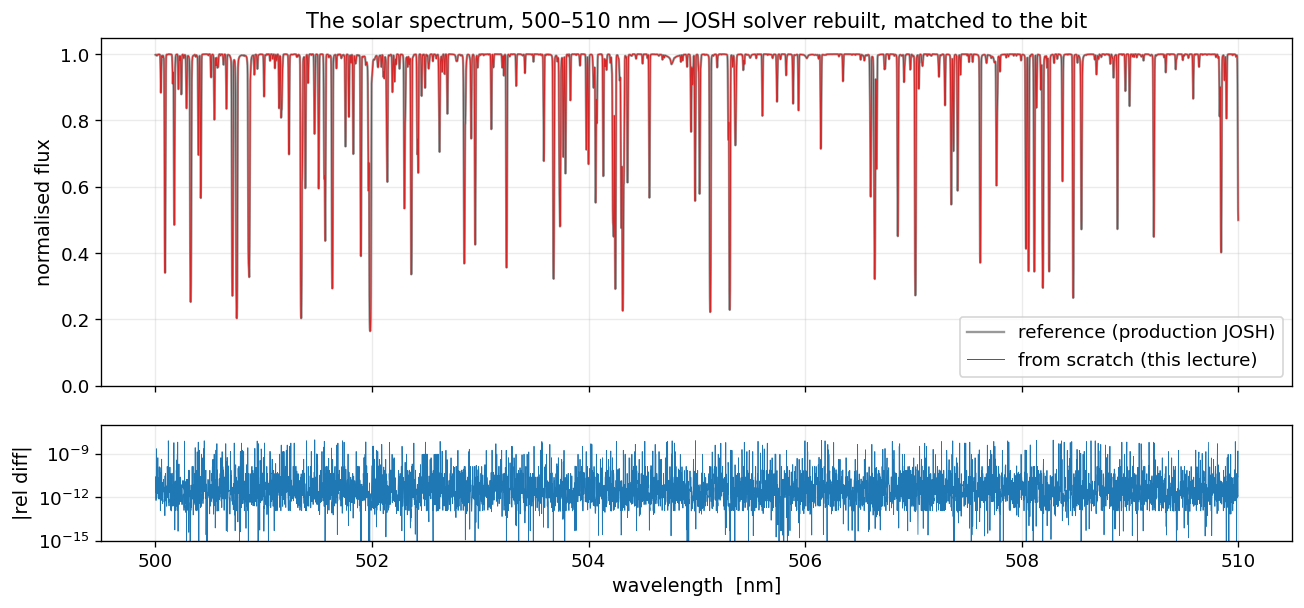

In [13]:
fig, (ax, axr) = plt.subplots(2, 1, figsize=(11, 5.2), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1]})

# top: the two spectra overlaid (they should be indistinguishable)
ax.plot(wl, reference, color="0.6", lw=1.4, label="reference (production JOSH)")
ax.plot(wl, spectrum, color="C3", lw=0.6, label="from scratch (this lecture)")
ax.set_ylabel("normalised flux"); ax.set_ylim(0, 1.05); ax.legend(loc="lower right")
ax.set_title("The solar spectrum, 500–510 nm — JOSH solver rebuilt, matched to the bit")

# bottom: the relative residual on a log scale (floored so zeros are plottable)
axr.semilogy(wl, np.maximum(rel, 1e-16), color="C0", lw=0.5)
axr.set_xlabel("wavelength  [nm]"); axr.set_ylabel("|rel diff|"); axr.set_ylim(1e-15, 1e-7)

fig.tight_layout(); plt.show()

The two spectra are indistinguishable, and the residual panel sits near $10^{-12}$ across the whole window, rising only to the single-precision floor in the sharpest cores. We have rebuilt the production radiative-transfer engine — moments, closure, operator, iteration, flux — and it reproduces the reference exactly.

## A note on saturated cores

One branch of the production solver does not fire in this window and so we have not needed it: when the **surface** optical depth already exceeds the deepest point of the fixed grid ($\tau_\lambda[0] > \tau_{\rm max}$, the bottom end of `XTAU`), the entire atmosphere lies below the grid, there is no grid point above it to anchor the interpolation, and the code switches to solving the moment equations directly on the physical $\tau_\lambda$ scale. That happens only in extremely opaque, saturated cores — the molecular band heads of cool stars, not the optical solar window — and we will meet it when we add molecules. For every wavelength in the Sun from 500 to 510 nm, the surface optical depth is small and the grid path above is exact.

## Synthesis

The Lecture 7 calculation gave the physical picture — flux as a weighted average of the source over depth — and the spectrum to a part in a thousand against the production engine. This lecture supplied the engine that closes the last gap. Taking moments of the transfer equation and applying the Eddington closure turns angle-dependent transfer into two moment equations; discretising them on a fixed optical-depth grid turns the lambda-like operator into a matrix; and iterating the source $S = (1-\alpha)\bar S + \alpha J$ to self-consistency replaces the prescribed thermal source with one that responds to its own radiation field. Reusing the same parabolic integration, the same interpolation, and the same single-precision iteration as the production code, the result is the solar spectrum reproduced to machine precision.

With the microphysics (Lectures 2–6) and both radiative-transfer treatments (Lectures 7–8) in hand, the synthesis half of the pipeline is complete — and reproduces the production code bit for bit. What remains is to stop taking the **model atmosphere** as given: in Part IV we build the temperature and pressure structure ourselves, from hydrostatic and radiative equilibrium, and watch the spectrum settle onto the real Sun.

## Summary

- Taking **moments** of the transfer equation gives $dH/d\tau = J - S$ and $dK/d\tau = H$; the **Eddington closure** $K = \tfrac13 J$ shuts the system, and its solution is linear in the source, $J = \Lambda[S]$.
- The production solver ships $\Lambda$ as a matrix `COEFJ` on a **fixed 51-point optical-depth grid**, with flux weights `CH` for the surface flux $H(0) = \sum_k \texttt{CH}_k S_k$.
- The scattering source obeys $S = (1-\alpha)\bar S + \alpha\,(\texttt{COEFJ}\cdot S)$, solved by a backward Gauss–Seidel sweep in **single precision** to a $10^{-5}$ tolerance.
- The pipeline per wavelength is: **optical depth** (`parcoe`/`integ`) → **map onto the grid** (`map1`) → **iterate the source** → **weighted flux**.
- The rebuilt solver reproduces the reference spectrum to a **median of $\sim10^{-12}$**, closing the gap the Lecture 7 calculation left against the production engine.

## Practice exercises

**1. The closure in action.** Set $\alpha = 0$ everywhere in `solve_josh` (so the source never leaves $\bar S$) and compare the result with the Lecture 7 pure-absorption formal solution. State the tolerance you find, and identify which of the remaining differences come from the grid, the flux weighting, and the interpolation rather than from the physics. Then raise $\alpha$ by hand in a single core and watch the central depth grow — how much scattering is needed to darken the core by ten percent?

**2. The operator's reach.** Plot a few rows of `COEFJ` (say $k=5, 25, 45$) against grid index. How localised is the mean-intensity response, and how does its width compare with the spacing of the optical-depth grid? Relate this to why a scattering-dominated line core samples a nonlocal range of neighbouring optical depths rather than only the local temperature.

**3. Precision matters.** Change `iterate_source` to work in `float64` instead of `float32` and recompute the spectrum. Where does it differ from the reference, and by how much? Explain why matching the production code requires matching its working precision, not just its algorithm.

**4. Convergence.** Count the iterations to convergence as a function of the maximum scattering fraction $\alpha$ along the column (return the count from `iterate_source`). Why do scattering-dominated wavelengths take longer, and what does that imply for the cost of a full spectral synthesis?

## Further reading

- **Avrett, E. H. & Loeser, R. (1969). *SAO Special Report* 303.** The moment method with variable Eddington factors that the JOSH solver descends from.
- **Mihalas, D. (1978). *Stellar Atmospheres*, 2nd ed., Freeman.** Chapters 6–7 on the moment equations, the Eddington approximation, and $\Lambda$-iteration.
- **Hubeny, I. & Mihalas, D. (2014). *Theory of Stellar Atmospheres*, Princeton.** Chapters 11–13 on operator methods, accelerated lambda iteration, and the convergence of scattering problems.
- **Kurucz, R. L. (1970). *SAO Special Report* 309 (ATLAS).** The original code whose `PARCOE`, `INTEG`, `MAP1`, and JOSH routines we reproduce.
- **Kim, E. M. & Ting, Y.-S. (2026). [*pykurucz*](https://arxiv.org/abs/2603.11693).** The implementation our reference spectrum is computed with.